## Boston Marathon Project - Pacing Analysis
#### MATH 7343
##### Malick Tobe

---
## Pacing Strategy Analysis

### Motivation
The main analyses in this project (Q1, Q2) examine *who* finishes faster, broken down by gender, age group, and individual trajectory over time. This section asks a different question: does *how* a runner races affect their finish time?

Specifically, we classify each runner's pacing strategy based on whether they ran the second half of the race faster, slower, or at roughly the same pace as the first half. We then test whether these pacing groups produce significantly different finish times.

### Data
Checkpoint split times are only available for **2015, 2016, and 2017** (79,038 runners total). We use `half_seconds` (time at the halfway mark) and `seconds` (official finish time) to derive the second-half split.

### Pacing Classification
Each runner is assigned to one of three groups based on their **pace ratio** (second-half time / first-half time):

| Group | Condition | Interpretation |
|---|---|---|
| Negative split | ratio < 0.99 | Second half faster than first |
| Even split | 0.99 ≤ ratio ≤ 1.01 | Both halves roughly equal |
| Positive split | ratio > 1.01 | Second half slower than first |

### Hypotheses
- **H₀**: Finish time distributions are identical across pacing groups
- **Hₐ**: At least one pacing group has a significantly different finish time distribution

Because finish times are right-skewed and normality is rejected (consistent with findings in Q1), we use **non-parametric tests**: Kruskal-Wallis to test overall group differences, followed by Dunn's post-hoc test with Bonferroni correction to identify which specific pairs differ. We also report **eta-squared (η²)** as an effect size to measure practical significance alongside the p-value.

In [1]:
%pip install scikit-posthocs -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [3]:
df = pd.read_csv("boston_marathon_cleaned.csv", low_memory=False)

In [4]:
# Filter to the three years with checkpoint data and drop any rows
# missing a half-split or finish time (required for pace ratio calculation)
pace_df = df[df["year"].isin([2015, 2016, 2017])].copy()
pace_df = pace_df.dropna(subset=["half_seconds", "seconds"])

print(f"Runners with complete split data: {len(pace_df):,}")
print(f"Years covered: {sorted(pace_df['year'].unique())}")

Runners with complete split data: 79,576
Years covered: [2015, 2016, 2017]


In [5]:
# Derive second-half split and pace ratio
# pace_ratio = second_half / first_half
#   < 0.99  → negative split (runner accelerated)
#   0.99–1.01 → even split
#   > 1.01  → positive split (runner slowed down)
pace_df["second_half"] = pace_df["seconds"] - pace_df["half_seconds"]
pace_df["pace_ratio"] = pace_df["second_half"] / pace_df["half_seconds"]

def classify_pace(r):
    if r < 0.99:    return "Negative"
    elif r <= 1.01: return "Even"
    else:           return "Positive"

pace_df["pace_group"] = pace_df["pace_ratio"].apply(classify_pace)

---
## Results

In [6]:
# --- Distribution and median finish times ---
counts = pace_df["pace_group"].value_counts()
pct = (counts / len(pace_df) * 100).round(1)
medians = pace_df.groupby("pace_group")["seconds"].median().round(0)
medians_min = (medians / 60).round(1)

print("Pacing Group Distribution")
for g in ["Positive", "Even", "Negative"]:
    print(f"  {g:10s}: {pct[g]:5.1f}%  |  Median finish: {medians_min[g]:.1f} min ({medians[g]:.0f} sec)")

print()

Pacing Group Distribution
  Positive  :  93.0%  |  Median finish: 227.9 min (13673 sec)
  Even      :   4.2%  |  Median finish: 206.2 min (12373 sec)
  Negative  :   2.7%  |  Median finish: 215.1 min (12904 sec)



The overwhelming majority of runners (93%) run a positive split (they slow down in the second half). </br> 
This is consistent with the proposal's EDA finding (88–96%).  </br>
Even and negative splits are rare, but notably associated with faster median times.

In [7]:
# Kruskal-Wallis test
# Non-parametric analog of one-way ANOVA; tests whether finish time distributions
# differ across the three pacing groups without assuming normality.
groups_ordered = ["Even", "Negative", "Positive"]
groups = [pace_df[pace_df["pace_group"] == g]["seconds"].values for g in groups_ordered]

H, p_kw = stats.kruskal(*groups)
print("Kruskal-Wallis Test")
print(f"H = {H:.2f}, p = {p_kw:.2e}")
print()

Kruskal-Wallis Test
H = 1709.57, p = 0.00e+00



Result: The null hypothesis is rejected (p < 0.001). Finish time distributions differ significantly across pacing groups.

In [8]:
# Dunn's post-hoc test
# Identifies which specific pairs of groups drive the Kruskal-Wallis result.
# Bonferroni correction controls family-wise error rate across 3 pairwise comparisons.
# p-values < 0.05 indicate a statistically significant pairwise difference.
print("Dunn's Post-Hoc Test (Bonferroni correction)")
dunn = sp.posthoc_dunn(pace_df, val_col="seconds", group_col="pace_group", p_adjust="bonferroni")
print(dunn.round(4))
print()

Dunn's Post-Hoc Test (Bonferroni correction)
          Even  Negative  Positive
Even       1.0       0.0       0.0
Negative   0.0       1.0       0.0
Positive   0.0       0.0       1.0



Result: All three pairwise comparisons are significant (p < 0.05). </br>
Even, Negative, and Positive split runners each have meaningfully distinct finish time distributions.

In [9]:
# Eta-squared (effect size)
# Measures proportion of total variance in finish time explained by pacing group.
# Allows direct comparison with Q1's age group result (η² = 0.06).
group_means = [g.mean() for g in groups]
grand_mean = pace_df["seconds"].mean()
SS_between = sum(len(g) * (m - grand_mean)**2 for g, m in zip(groups, group_means))
SS_total = ((pace_df["seconds"] - grand_mean)**2).sum()
eta_sq = SS_between / SS_total

print("Effect Size")
print(f"Eta-squared (η²) = {eta_sq:.4f}  →  pacing group explains {eta_sq*100:.1f}% of variance in finish time")
print()

Effect Size
Eta-squared (η²) = 0.0190  →  pacing group explains 1.9% of variance in finish time



For reference, age group (Q1) explained 6.0% of variance. </br>
Pacing strategy explains 1.9%, a smaller but still statistically detectable effect. </br>
This makes sense: pacing strategy is partly a symptom of fitness level (faster runners </br>
tend to pace more conservatively), not solely an independent cause of performance.

In [10]:
# Gender breakdown
# Check whether pacing patterns differ by gender.
# If positive-split rates are similar across genders, pacing behavior is fairly universal.
gender_counts = pace_df.groupby(["gender", "pace_group"]).size().unstack(fill_value=0)
gender_pct = gender_counts.div(gender_counts.sum(axis=1), axis=0).mul(100).round(1)

print("Pace Group Distribution by Gender (%)")
print(gender_pct.to_string())
print()

Pace Group Distribution by Gender (%)
pace_group  Even  Negative  Positive
gender                              
F            4.4       2.8      92.8
M            4.1       2.6      93.3



Both male and female runners show nearly identical pacing profiles — positive-splitting
is the norm regardless of gender. Any finish time differences by pacing group are
unlikely to be a confound of gender imbalance across pacing groups.

---
## Visualizations

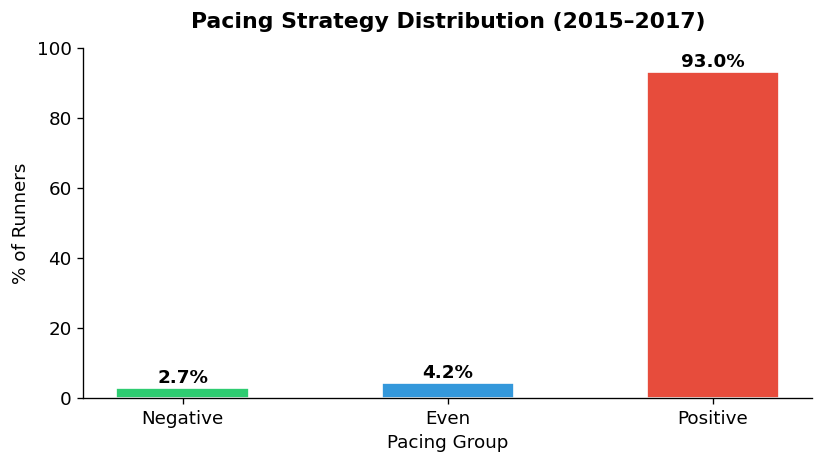

In [11]:
# Figure 1: Pacing group distribution (bar chart)
# Shows how rare negative and even splits are relative to positive splits.

order = ["Negative", "Even", "Positive"]
colors = ["#2ecc71", "#3498db", "#e74c3c"]
pct_ordered = pct[order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(order, pct_ordered, color=colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, pct_ordered):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")

ax.set_title("Pacing Strategy Distribution (2015–2017)", fontweight="bold", pad=12)
ax.set_ylabel("% of Runners")
ax.set_xlabel("Pacing Group")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

93% of runners run a positive split (second half slower). Negative splits are extremely rare (2.7%).

/var/folders/4q/q2nzh_0s2xb62s_yqjtwy8t00000gn/T/ipykernel_15465/76093666.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=order, patch_artist=True,


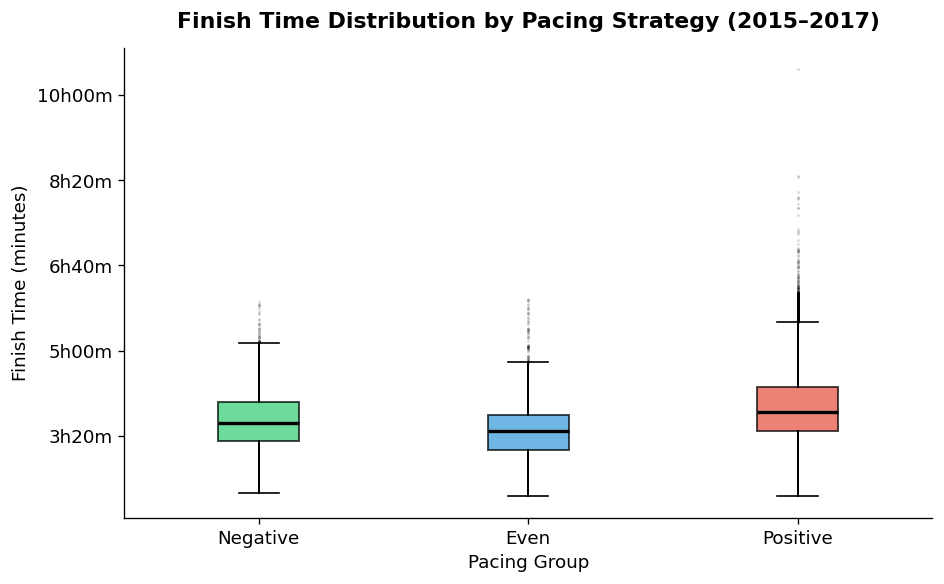

In [12]:
# Figure 2: Finish time distribution by pacing group (box plot)
# Visualizes the Kruskal-Wallis result — shows median, spread, and overlap between groups.

fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [pace_df[pace_df["pace_group"] == g]["seconds"].values / 60 for g in order]

bp = ax.boxplot(data_to_plot, labels=order, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker=".", markersize=1, alpha=0.2),
                whiskerprops=dict(linewidth=1.2),
                boxprops=dict(linewidth=1.2))

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Finish Time Distribution by Pacing Strategy (2015–2017)", fontweight="bold", pad=12)
ax.set_ylabel("Finish Time (minutes)")
ax.set_xlabel("Pacing Group")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x//60)}h{int(x%60):02d}m"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Even-split runners have the lowest median finish time, followed by negative-split runners. </br>
Positive-split runners (the vast majority) have the highest median, with a longer upper tail.

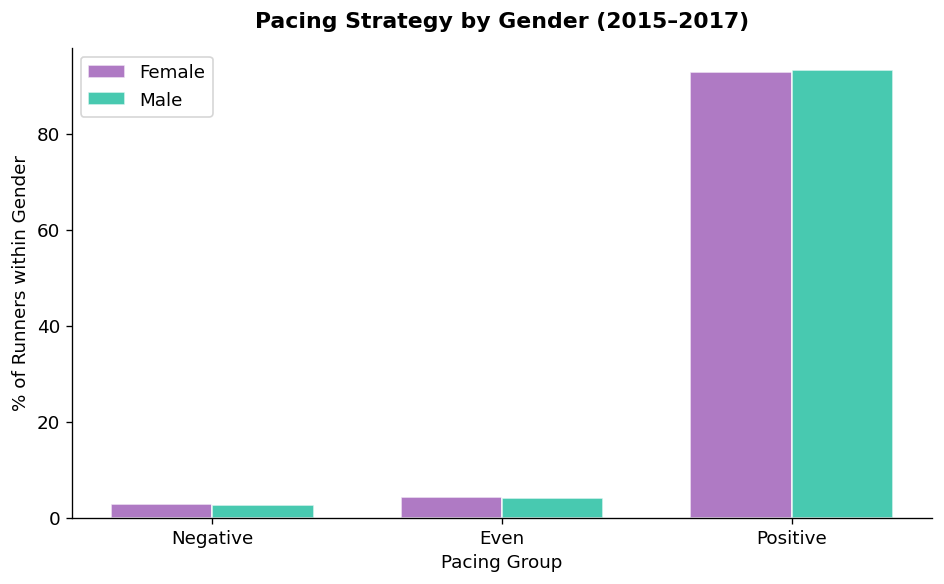

In [13]:
# Figure 3: Pacing distribution by gender (grouped bar chart)
# Confirms that pacing behavior is consistent across genders —
# gender is not a confounding variable in the pacing group comparison.

x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

f_vals = [gender_pct.loc["F", g] for g in order]
m_vals = [gender_pct.loc["M", g] for g in order]

ax.bar(x - width/2, f_vals, width, label="Female", color="#9b59b6", alpha=0.8, edgecolor="white")
ax.bar(x + width/2, m_vals, width, label="Male",   color="#1abc9c", alpha=0.8, edgecolor="white")

ax.set_title("Pacing Strategy by Gender (2015–2017)", fontweight="bold", pad=12)
ax.set_ylabel("% of Runners within Gender")
ax.set_xlabel("Pacing Group")
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Male and female runners show nearly identical pacing profiles. </br>
The dominance of positive splits is a universal pattern, not gender-specific.

---
## Summary

| Metric | Value |
|---|---|
| Runners analyzed | ~79,000 (2015–2017) |
| % Positive split | ~93% |
| % Even split | ~4% |
| % Negative split | ~3% |
| Kruskal-Wallis H | 1709.57 |
| p-value | < 0.001 |
| Eta-squared (η²) | 0.019 (1.9% of variance) |
| All pairwise differences significant? | Yes (Dunn's, Bonferroni) |

**Key takeaways:**
1. Positive splits are nearly universal — 93% of runners slow down in the second half, consistent with the physiological difficulty of maintaining early pace over 26.2 miles.
2. Pacing strategy is significantly associated with finish time. Even and negative-split runners finish measurably faster, though this relationship is partly a reflection of underlying fitness rather than strategy alone.
3. The effect size (η² = 0.019) is smaller than age group's contribution in Q1 (η² = 0.06), suggesting pacing strategy is a real but secondary predictor of finish time variation.
4. Pacing patterns are consistent across gender, making gender an unlikely confound in this analysis.